<a href="https://colab.research.google.com/github/OvoFiona/Fraud-Detection/blob/main/FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Libraries and loading dataset
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset from the uploaded CSV file
print("Please upload the 'bank_transaction_data_2.csv' file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

Please upload the 'bank_transaction_data_2.csv' file:


Saving bank_transactions_data_2.csv to bank_transactions_data_2.csv


In [2]:
#Displaying basic information about the dataset
print("="*50)
print("BASIC DATASET INFORMATION")
print("="*50)
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())

BASIC DATASET INFORMATION
Dataset shape: (2512, 16)
Number of rows: 2512
Number of columns: 16

Column names:
['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']

Data types:
TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object

First 5 rows:
  Transaction

DATA CLEANING

MISSING VALUES CHECK
                         Missing Values  Percentage
TransactionID                         0         0.0
AccountID                             0         0.0
TransactionAmount                     0         0.0
TransactionDate                       0         0.0
TransactionType                       0         0.0
Location                              0         0.0
DeviceID                              0         0.0
IP Address                            0         0.0
MerchantID                            0         0.0
Channel                               0         0.0
CustomerAge                           0         0.0
CustomerOccupation                    0         0.0
TransactionDuration                   0         0.0
LoginAttempts                         0         0.0
AccountBalance                        0         0.0
PreviousTransactionDate               0         0.0


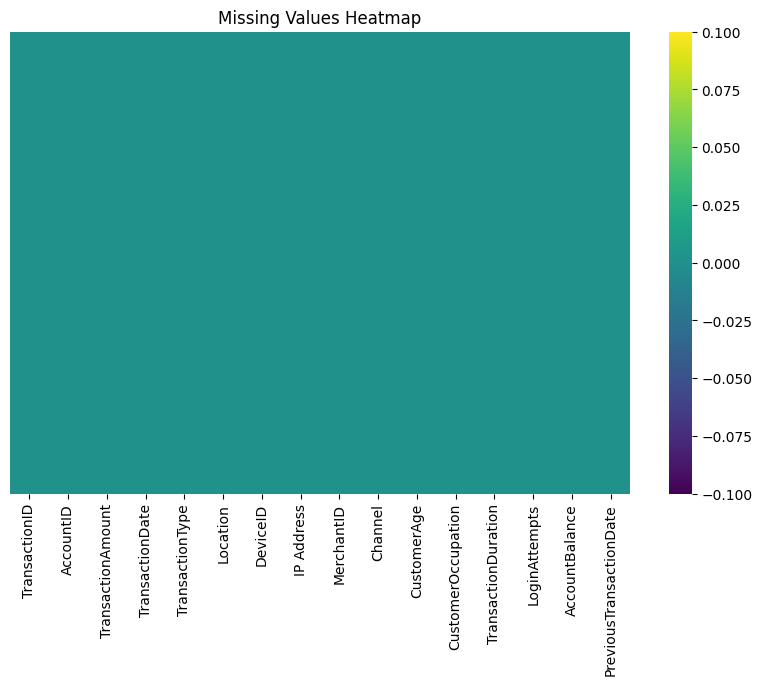

In [3]:
#Check for missing values
print("="*50)
print("MISSING VALUES CHECK")
print("="*50)
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
print(missing_df)

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [5]:
#Check for duplicate rows
print("="*50)
print("DUPLICATE ROWS CHECK")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

#Check for duplicate transactions
duplicate_transactions = df.duplicated(subset=['TransactionID']).sum()
print(f"Duplicate Transaction IDs: {duplicate_transactions}")

#If duplicates exist, remove them
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")

DUPLICATE ROWS CHECK
Number of duplicate rows: 0
Duplicate Transaction IDs: 0


In [7]:
#Data type conversion and validation
print("="*50)
print("DATA TYPE VALIDATION")
print("="*50)

# Check current data types
print("Current data types:")
print(df.dtypes)

# Convert date columns to datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

# Calculate time difference between transactions
df['DaysSinceLastTransaction'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds() / (24 * 3600)
print(f"Time range between transactions: {df['DaysSinceLastTransaction'].min():.2f} to {df['DaysSinceLastTransaction'].max():.2f} days")

print("\nUpdated data types:")
print(df.dtypes)

DATA TYPE VALIDATION
Current data types:
TransactionID                       object
AccountID                           object
TransactionAmount                  float64
TransactionDate             datetime64[ns]
TransactionType                     object
Location                            object
DeviceID                            object
IP Address                          object
MerchantID                          object
Channel                             object
CustomerAge                          int64
CustomerOccupation                  object
TransactionDuration                  int64
LoginAttempts                        int64
AccountBalance                     float64
PreviousTransactionDate     datetime64[ns]
DaysSinceLastTransaction           float64
dtype: object
Time range between transactions: -671.67 to -307.57 days

Updated data types:
TransactionID                       object
AccountID                           object
TransactionAmount                  float64
Transac

In [8]:
#Check for Outliers
print("="*50)
print("OUTLIER DETECTION")
print("="*50)

#Select numerical columns for outlier detection
numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
                  'LoginAttempts', 'AccountBalance', 'DaysSinceLastTransaction']

#Using IQR method to detect outliers
outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'Total Outliers': len(outliers),
        'Percentage': (len(outliers) / len(df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

OUTLIER DETECTION
                          Total Outliers  Percentage
TransactionAmount                  113.0    4.498408
CustomerAge                          0.0    0.000000
TransactionDuration                  0.0    0.000000
LoginAttempts                      122.0    4.856688
AccountBalance                       0.0    0.000000
DaysSinceLastTransaction             0.0    0.000000
